<a href="https://colab.research.google.com/github/Larafigueroa/Prep-Course/blob/main/TP_Version_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
#Librerias usadas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



In [6]:
df = pd.read_excel('/content/Data_heatStress (2).xlsx', skiprows=2)
df

,Sl.No.,Accession ID,Accession Name,ExomeCapture_ID,GWAS Panel (Id),Replication,Treatment,Coleoptile length (CL; cm),Shoot length (SL; cm),Root length (RL; cm),Root number (RN),Shoot fresh weight (SFW; mg),Root fresh weight (RFW; mg)
0,1,CItr 2804,CI 2804,ExomeCapture-Cltr-2804,SD-ExDiv-001,R1,Non-heat stress (23 °C),2.50,14.50,41.50,5.0,10.06,15.93
1,2,CITR 4175,Saracen,ExomeCapture-Cltr-4175,SD-ExDiv-002,R1,Non-heat stress (23 °C),2.50,16.70,43.65,5.5,7.36,30.90
2,3,CItr 7635,CI 7635,ExomeCapture-Cltr-7635,SD-ExDiv-005,R1,Non-heat stress (23 °C),2.80,19.50,41.75,5.0,12.22,27.17
3,4,CItr 7706,Chorol,ExomeCapture-DAS5-003961,SD-ExDiv-006,R1,Non-heat stress (23 °C),2.95,20.70,37.50,5.5,9.88,18.08
4,5,CItr 11223,Croatia 1,ExomeCapture-Cltr-11223,SD-ExDiv-009,R1,Non-heat stress (23 °C),2.00,16.35,42.10,4.5,8.68,19.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,212,PI 641166,CJ 9311,ExomeCapture-DAS5-001309,SD-ExDiv-402,R3,Heat stress (36 °C),1.90,10.55,4.95,8.0,7.23,6.60
1292,213,PI 641762,SSL 91-94,ExomeCapture-DAS5-004590,SD-ExDiv-404,R3,Heat stress (36 °C),2.20,12.00,4.15,8.0,0.67,5.02
1293,214,PI 642365,IDO629,ExomeCapture-DAS5-001496,SD-ExDiv-405,R3,Heat stress (36 °C),2.15,10.10,5.30,6.0,4.30,1.30
1294,215,PI 644146,PI351993-sel-fhb,ExomeCapture-DAS5-001756,SD-ExDiv-406,R3,Heat stress (36 °C),2.75,13.35,2.65,6.5,6.83,4.33


In [7]:
#revisar dimensiones
print ('filas y columnas: ', df.shape )
df.columns


filas y columnas:  (1296, 13)


Index(['Sl.No.', 'Accession ID', 'Accession Name', 'ExomeCapture_ID',
       'GWAS Panel (Id)', 'Replication', 'Treatment',
       'Coleoptile length (CL; cm)', 'Shoot length (SL; cm)',
       'Root length (RL; cm)', 'Root number (RN)',
       'Shoot fresh weight (SFW; mg)', 'Root fresh weight (RFW; mg)'],
      dtype='object')

In [10]:
df.info() #Veo como estan conformadas las columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sl.No.                        1296 non-null   int64  
 1   Accession ID                  1296 non-null   object 
 2   Accession Name                1296 non-null   object 
 3   ExomeCapture_ID               1296 non-null   object 
 4   GWAS Panel (Id)               1296 non-null   object 
 5   Replication                   1296 non-null   object 
 6   Treatment                     1296 non-null   object 
 7   Coleoptile length (CL; cm)    1296 non-null   float64
 8   Shoot length (SL; cm)         1296 non-null   float64
 9   Root length (RL; cm)          1296 non-null   float64
 10  Root number (RN)              1296 non-null   float64
 11  Shoot fresh weight (SFW; mg)  1296 non-null   float64
 12  Root fresh weight (RFW; mg)   1296 non-null   float64
dtypes: 

In [11]:
#Ahora quiero entender si hay NAs; No tenemos NAs
df.isna().sum()

,0
Sl.No.,0
Accession ID,0
Accession Name,0
ExomeCapture_ID,0
GWAS Panel (Id),0
Replication,0
Treatment,0
Coleoptile length (CL; cm),0
Shoot length (SL; cm),0
Root length (RL; cm),0


In [14]:
#Renombrar las columnas para que sea más legible
df.rename(columns={
    "Accession Name":"Variedad",
    "Coleoptile length (CL; cm)": "CL",
    "Shoot length (SL; cm)": "SL",
    "Root length (RL; cm)": "RL",
    "Root number (RN)": "RN",
    'Shoot fresh weight (SFW; mg)': "SFW",
    'Root fresh weight (RFW; mg)': "RFW"
}, inplace=True)
df.columns

Index(['Sl.No.', 'Accession ID', 'Variedad', 'ExomeCapture_ID',
       'GWAS Panel (Id)', 'Replication', 'Treatment', 'CL', 'SL', 'RL', 'RN',
       'SFW', 'RFW'],
      dtype='object')

In [16]:
#Data duplicada
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)


Empty DataFrame
Columns: [Sl.No., Accession ID, Variedad, ExomeCapture_ID, GWAS Panel (Id), Replication, Treatment, CL, SL, RL, RN, SFW, RFW]
Index: []


In [19]:
df.describe()
#El valor mínimo de SFW es raro , no debería haber negativos, hay que eliminar ese dato

,Sl.No.,CL,SL,RL,RN,SFW,RFW
count,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000,1296.000000
mean,108.500000,2.513272,15.149923,19.308989,5.884452,10.400918,13.704429
std,62.377231,0.497295,5.146721,15.412265,1.371947,5.395792,11.399165
min,1.000000,0.900000,3.500000,1.000000,2.000000,-2.860000,0.030000
25%,54.750000,2.150000,11.050000,4.500000,5.000000,6.170000,3.600000
50%,108.500000,2.500000,14.600000,11.650000,6.000000,9.850000,10.000000
75%,162.250000,2.850000,19.000000,33.250000,7.000000,14.147500,23.415000
max,216.000000,4.500000,34.500000,55.000000,12.000000,28.400000,47.520000


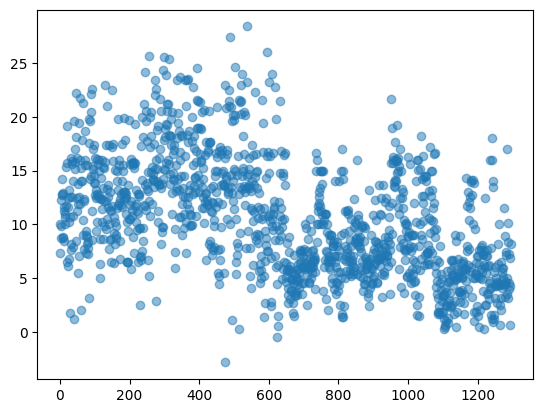

In [26]:
plt.scatter(df.index, df['SFW'], alpha=0.5)
plt.show()

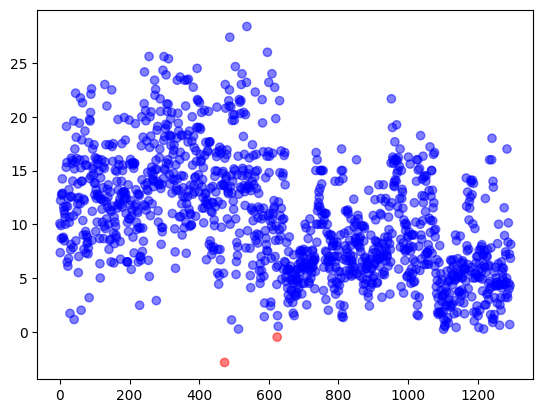

In [31]:
#Quiero ver los puntos que son negativos
color_anorm= np.where(df['SFW']<=0, 'red','blue')
plt.scatter(df.index, df['SFW'],c=color_anorm, alpha=0.5)
plt.show()

In [32]:
#Ahora quiero ver que fila es
df[df['SFW']<0 ]
#Elimino estas filas? yo las eliminaria porque tenemos mucha info, no corremos riesgo de perder tanta data. Qué opinas?

,Sl.No.,Accession ID,Variedad,ExomeCapture_ID,GWAS Panel (Id),Replication,Treatment,CL,SL,RL,RN,SFW,RFW
473,42,PI 115838,4453/31,ExomeCapture-DAS5-003578,SD-ExDiv-063,R3,Non-heat stress (23 °C),3.50,20.5,40.00,5.0,-2.86,14.12
624,193,PI 574350,15067,ExomeCapture-DAS5-003977,SD-ExDiv-362,R3,Non-heat stress (23 °C),1.95,12.3,37.75,4.5,-0.50,13.73


In [33]:
df_clean = df[df['SFW']>=0]
df_clean.shape

(1294, 13)

In [34]:
#Estadísticas descriptivas
df_clean.describe()

,Sl.No.,CL,SL,RL,RN,SFW,RFW
count,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000
mean,108.486090,2.512944,15.147991,19.278748,5.886206,10.419590,13.704088
std,62.353787,0.496675,5.147940,15.404880,1.372246,5.378787,11.407972
min,1.000000,0.900000,3.500000,1.000000,2.000000,0.230000,0.030000
25%,55.000000,2.150000,11.050000,4.500000,5.000000,6.200000,3.600000
50%,108.500000,2.500000,14.600000,11.200000,6.000000,9.875000,9.955000
75%,162.000000,2.850000,19.000000,33.187500,7.000000,14.162500,23.425000
max,216.000000,4.500000,34.500000,55.000000,12.000000,28.400000,47.520000


In [35]:
df['Variedad'].value_counts()
#Tenemos 6 rep por variedad

,count
Variedad,
CI 2804,6
Saracen,6
CI 7635,6
Chorol,6
Croatia 1,6
...,...
CJ 9311,6
SSL 91-94,6
IDO629,6


In [36]:
pd.crosstab(df_clean['Variedad'],df_clean['Treatment'])
#Tenemos 216 variedades con 6 rep cada variedad separadas en 3 rep por tratamiento

Treatment,Heat stress (36 °C),Non-heat stress (23 °C)
Variedad,,
3,3,3
17,3,3
37,3,3
60,3,3
76,3,3
...,...,...
Tucursindi,3,3
Tunis 23,3,3
VI 121.2.13B.2T.2B,3,3


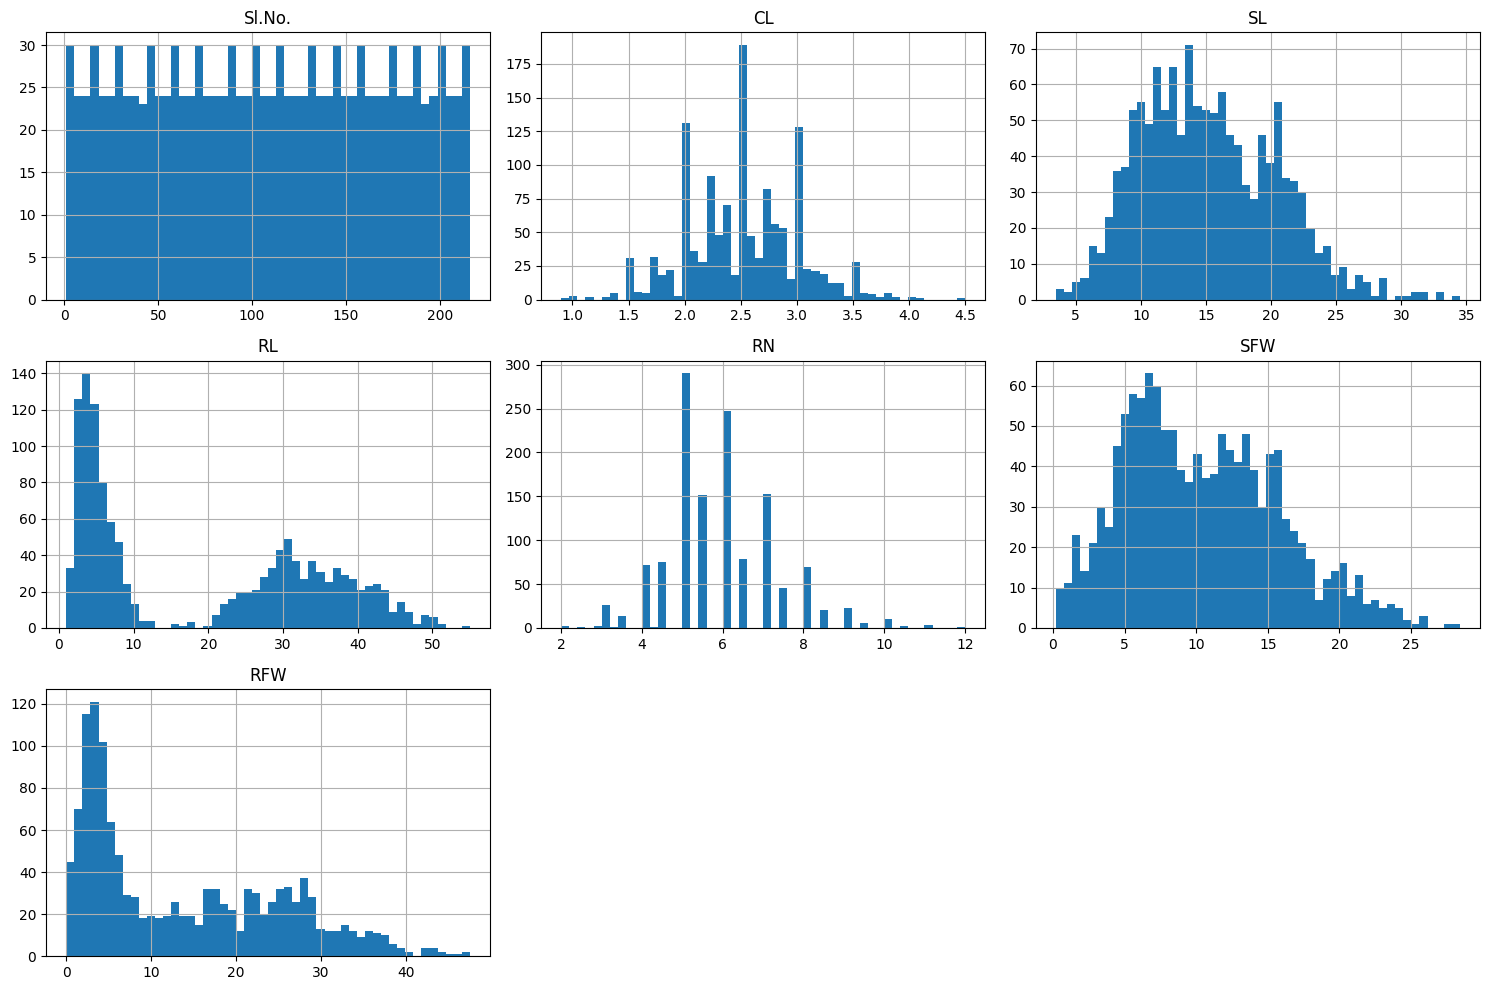

In [39]:
df_clean.hist(bins=50, figsize=(15, 10), layout=(3, 3))
plt.tight_layout()
plt.show()
#En algunas variables se observa una tendencia bimodal como por ejemplo RL,SL,SFW,RFW, no recuerdo que importancia tiene la variable RN (Root number)

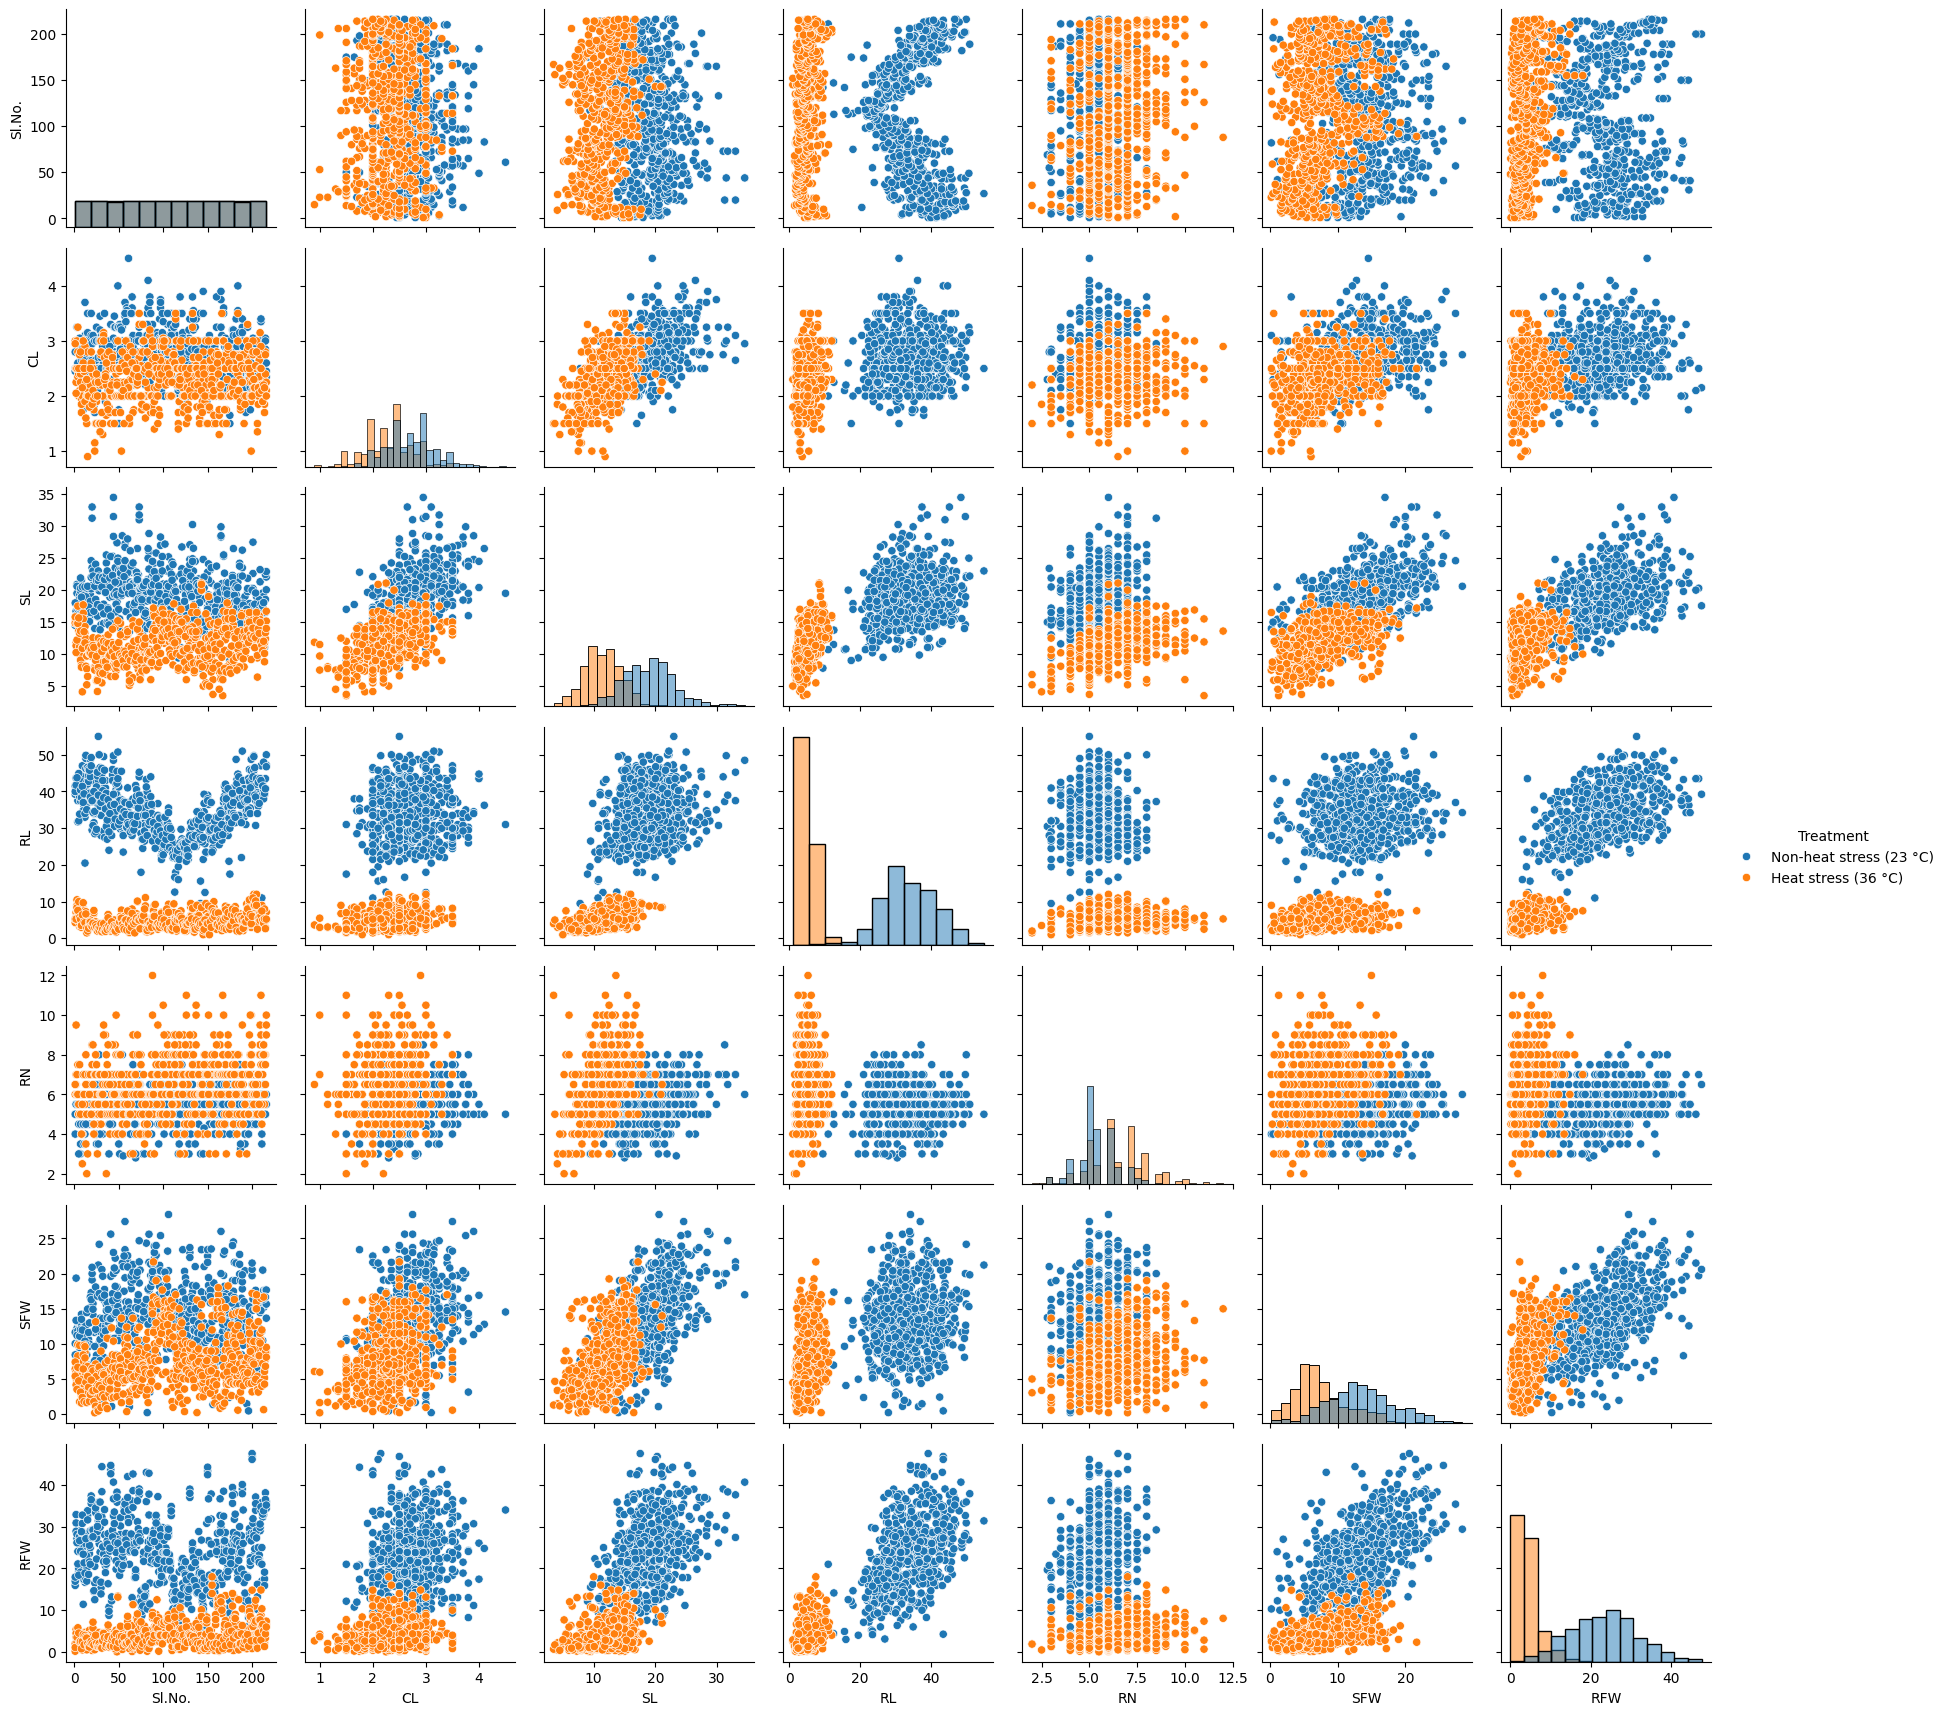

In [41]:
g = sns.PairGrid(df_clean, hue="Treatment")
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
#Quiero hacer un gráfico de este estilo, se nota que hay dif en la respuesta a los tratamientos

In [42]:
#Variables que quiero analizar
variables= [
    'CL',
    'SL',
    'RL',
    'RN',
    'SFW',
    'RFW'
]

In [50]:
df_melt = pd.melt(df_clean,
                  id_vars=['Treatment'],
                  value_vars= variables,
                  var_name='Variable',
                  value_name='Valor')

/tmp/ipykernel_3414/1146214325.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


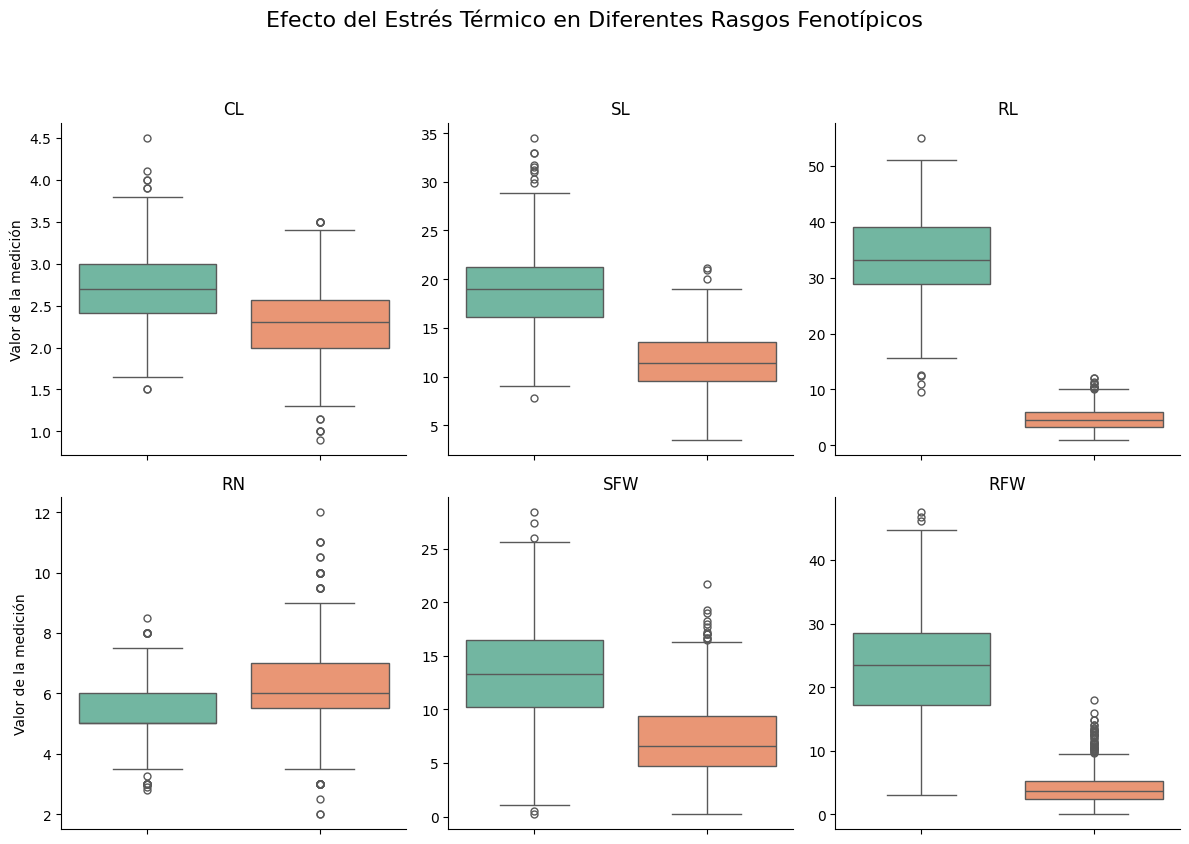

In [51]:
g = sns.catplot(
    data=df_melt,
    x='Treatment',
    y='Valor',
    col='Variable',      # Crear un gráfico por variable
    kind='box',          # Tipo de gráfico (boxplot)
    col_wrap=3,          # 3 gráficos por fila (2 filas x 3 columnas)
    sharey=False,        # ¡Importante! Cada gráfico mantiene su propia escala Y
    palette='Set2',      # Paleta de colores
    height=4,            # Altura de cada panel
    aspect=1             # Proporción de cada panel
)

# 5. Ajustes estéticos finales
g.set_titles(col_template="{col_name}", size=12)
g.set_axis_labels("", "Valor de la medición")
g.set_xticklabels(rotation=0)

# Título principal general
g.fig.suptitle('Efecto del Estrés Térmico en Diferentes Rasgos Fenotípicos', y=1.05, fontsize=16)

# Ajustar márgenes y guardar/mostrar
plt.tight_layout()
plt.show()

#En este no sé porque no puedo mostrar la leyenda de que tratamiento corresponde cada color


In [54]:
df_clean[variables].corr(numeric_only=True)
#La variable Si.No me está ensuciando el analisis


,CL,SL,RL,RN,SFW,RFW
CL,1.000000,0.641051,0.421628,0.013266,0.437312,0.421196
SL,0.641051,1.000000,0.751858,-0.048721,0.709784,0.770569
RL,0.421628,0.751858,1.000000,-0.355537,0.566737,0.875316
RN,0.013266,-0.048721,-0.355537,1.000000,-0.025559,-0.228598
SFW,0.437312,0.709784,0.566737,-0.025559,1.000000,0.710142
RFW,0.421196,0.770569,0.875316,-0.228598,0.710142,1.000000


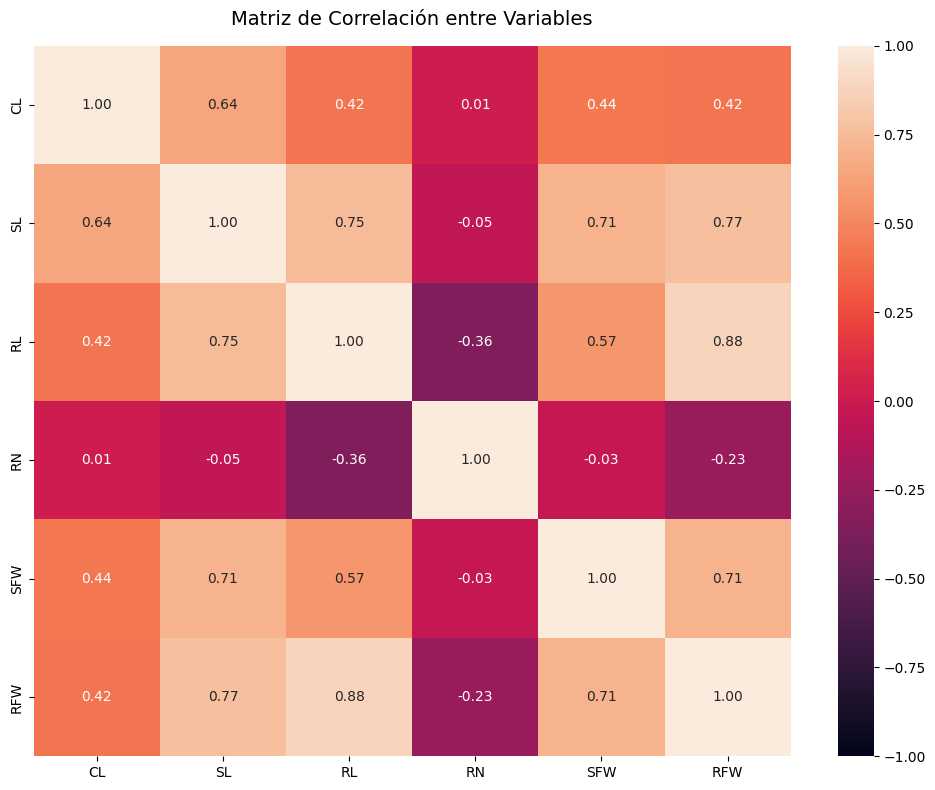

In [55]:
plt.figure (figsize= (10,8))
sns.heatmap (
    df_clean[variables].corr(numeric_only=True),
    annot= True,
    fmt=".2f",
    vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Variables', fontsize=14, pad=15)
plt.tight_layout()
plt.show()